# **T20 Cricket Win Probability Simulator**

# Overview

This notebook builds a ball-by-ball T20 cricket win probability model. Given the current match state at any completed over — runs scored, wickets fallen, target, teams, venue — the model outputs the probability that the chasing team wins.

**Key design decisions:**
- Trained on 10,458 matches across 10 T20 leagues (2008–2026) from [Cricsheet](https://cricsheet.org)
- Temporal train/test split (2008–2024 train, 2025–2026 test) to avoid data leakage
- XGBoost with isotonic calibration, benchmarked against a Logistic Regression baseline
- SHAP used for feature importance and per-prediction explainability
- Deployed as a multi-page Streamlit app: live predictor, full match replay, famous match case studies, and model insights

**Final model performance (2025–2026 holdout):** AUC 0.924, Log Loss 0.345, Brier Score 0.112

# Data Collection

Match data comes from Cricsheet, which provides free ball-by-ball JSON files for professional cricket matches. Using 10,458 matches across 10 T20 leagues (2008-2026) instead of just IPL gives more training data and more varied match conditions.

In [9]:
import json
import pandas as pd
import os

# Point this to your extracted folder
data_path = "/Users/granthbangard/Local Files/Documents/granth/UIUC/CS Projects/3. T20 Win Probability/consol_json"

files = [f for f in os.listdir(data_path) if f.endswith('.json') and f != 'README.json']
print(f"Total match files: {len(files)}")

Total match files: 10458


**Parsing summary:** 2,399,353 balls parsed across 10,458 matches into a single dataframe.

In [10]:
from pathlib import Path

data_path = "/Users/granthbangard/Local Files/Documents/granth/UIUC/CS Projects/3. T20 Win Probability/consol_json"

records = []

for filename in os.listdir(data_path):
    if not filename.endswith('.json') or filename == 'README.json':
        continue
    
    with open(os.path.join(data_path, filename)) as f:
        match = json.load(f)
    
    info = match['info']
    innings_list = match.get('innings', [])
    
    # Match metadata
    match_id = filename.replace('.json', '')
    date = info['dates'][0]
    teams = info['teams']
    venue = info.get('venue', None)
    city = info.get('city', None)
    competition = info.get('event', {}).get('name', 'Unknown')
    match_type = info.get('match_type', 'T20')
    
    # Winner
    outcome = info.get('outcome', {})
    winner = outcome.get('winner', None)
    
    for innings_idx, innings in enumerate(innings_list):
        batting_team = innings['team']
        bowling_team = [t for t in teams if t != batting_team][0]
        innings_num = innings_idx + 1
        
        balls = []
        for over_data in innings.get('overs', []):
            over_num = over_data['over']
            for ball_data in over_data['deliveries']:
                balls.append({
                    'match_id': match_id,
                    'date': date,
                    'competition': competition,
                    'venue': venue,
                    'city': city,
                    'batting_team': batting_team,
                    'bowling_team': bowling_team,
                    'innings': innings_num,
                    'over': over_num,
                    'runs_off_bat': ball_data['runs']['batter'],
                    'extras': ball_data['runs']['extras'],
                    'runs_on_ball': ball_data['runs']['total'],
                    'wicket': 1 if 'wickets' in ball_data else 0,
                    'winner': winner
                })
        
        records.extend(balls)

df_balls = pd.DataFrame(records)
print(df_balls.shape)
df_balls.head()

(2399353, 14)
  match_id        date              competition  \
0  1442989  2024-07-30  India tour of Sri Lanka   
1  1442989  2024-07-30  India tour of Sri Lanka   
2  1442989  2024-07-30  India tour of Sri Lanka   
3  1442989  2024-07-30  India tour of Sri Lanka   
4  1442989  2024-07-30  India tour of Sri Lanka   

                                     venue   city batting_team bowling_team  \
0  Pallekele International Cricket Stadium  Kandy        India    Sri Lanka   
1  Pallekele International Cricket Stadium  Kandy        India    Sri Lanka   
2  Pallekele International Cricket Stadium  Kandy        India    Sri Lanka   
3  Pallekele International Cricket Stadium  Kandy        India    Sri Lanka   
4  Pallekele International Cricket Stadium  Kandy        India    Sri Lanka   

   innings  over  runs_off_bat  extras  runs_on_ball  wicket winner  
0        1     0             0       0             0       0   None  
1        1     0             1       0             1       0   N

## Missing Winners

In [61]:
print(df_balls['winner'].isna().sum(), '\n')
print(df_balls['winner'].value_counts().head(10))

42924 

winner
India                  62883
England                56660
Australia              54563
Pakistan               51701
New Zealand            46936
South Africa           44473
West Indies            38001
Mumbai Indians         37151
Chennai Super Kings    35839
Sri Lanka              33764
Name: count, dtype: int64


**Finding:** 42,924 balls (~2%) have no recorded winner - abandoned or no-result matches, dropped later.

# Building Match State

## Over-Level 

The model predicts win probability at the end of each over, not ball-by-ball. Over-level granularity avoids the noisy, non-monotonic swings that ball-level predictions can produce.

Only 2nd innings (chasing team) data is used, since that's the natural framing for a live win probability tracker. This builds one row per over with cumulative runs, wickets, and the match winner, dropping the ~2% of matches with no recorded winner.

In [12]:
df_2nd = df_balls[df_balls['innings'] == 2].copy()

# Cumulative runs and wickets at each ball
df_2nd = df_2nd.sort_values(['match_id', 'over', ])
df_2nd['cumul_runs'] = df_2nd.groupby('match_id')['runs_on_ball'].cumsum()
df_2nd['cumul_wickets'] = df_2nd.groupby('match_id')['wicket'].cumsum()

# Last ball of each over (end-of-over state)
df_over = df_2nd.groupby(['match_id', 'over']).last().reset_index()

df_over = df_over.dropna(subset=['winner'])

# Target variable
df_over['chasing_team_wins'] = (df_over['winner'] == df_over['batting_team']).astype(int)

print(df_over.shape)
df_over[['match_id', 'over', 'cumul_runs', 'cumul_wickets', 'batting_team', 'winner', 'chasing_team_wins']].head(20)

(179734, 17)


,match_id,over,cumul_runs,cumul_wickets,batting_team,winner,chasing_team_wins
0,1001349,0,5,1,Sri Lanka,Sri Lanka,1
1,1001349,1,15,1,Sri Lanka,Sri Lanka,1
2,1001349,2,22,1,Sri Lanka,Sri Lanka,1
3,1001349,3,46,1,Sri Lanka,Sri Lanka,1
4,1001349,4,51,1,Sri Lanka,Sri Lanka,1
5,1001349,5,62,1,Sri Lanka,Sri Lanka,1
6,1001349,6,67,1,Sri Lanka,Sri Lanka,1
7,1001349,7,73,1,Sri Lanka,Sri Lanka,1
8,1001349,8,80,2,Sri Lanka,Sri Lanka,1
9,1001349,9,88,2,Sri Lanka,Sri Lanka,1


## Rolling Features

In [62]:
df_over["runs_per_over"] = df_over.groupby('match_id')["cumul_runs"].diff()
df_over["runs_per_over"] = df_over["runs_per_over"].fillna(df_over["cumul_runs"]).astype(int)
df_over["runs_in_last_3_overs"] = df_over.groupby('match_id')["runs_per_over"].rolling(window = 3, min_periods=1).sum().reset_index(level=0, drop=True).astype(int)

In [63]:
df_over["wickets_per_over"] = df_over.groupby('match_id')["cumul_wickets"].diff()
df_over["wickets_per_over"] = df_over["wickets_per_over"].fillna(df_over["cumul_wickets"]).astype(int)
df_over["wickets_in_last_3_overs"] = df_over.groupby('match_id')["wickets_per_over"].rolling(window = 3, min_periods=1).sum().reset_index(level=0, drop=True).astype(int)
df_over[["runs_per_over", "runs_in_last_3_overs", "wickets_per_over", "wickets_in_last_3_overs"]].head(20)

,runs_per_over,runs_in_last_3_overs,wickets_per_over,wickets_in_last_3_overs
0,5,5,1,1
1,10,15,0,1
2,7,22,0,1
3,24,41,0,0
4,5,36,0,0
5,11,40,0,0
6,5,21,0,0
7,6,22,0,0
8,7,18,1,1
9,8,21,0,1


Cumulative totals don't capture momentum. A team that scored 40 in the last 3 overs is in a different position than one that scored 15, even with the same overall total. These rolling sums fix that.

**Check:** values reset cleanly at match boundaries, no bleed between matches.

## Target Score

In [15]:
df_1st = df_balls[df_balls["innings"] == 1]
df_target = df_1st.groupby("match_id")["runs_on_ball"].sum().reset_index()
df_target.columns = ["match_id", "target"]
df_target.target = df_target.target + 1 # Target is total runs by first team + 1.

df_over = df_over.merge(df_target, on = "match_id", how = "left")

print("Null targets:", df_over["target"].isna().sum())
df_over[['match_id', 'over', 'cumul_runs', 'cumul_wickets', 'target', 'chasing_team_wins']].head(20)

Null targets: 0


,match_id,over,cumul_runs,cumul_wickets,target,chasing_team_wins
0,1001349,0,5,1,169,1
1,1001349,1,15,1,169,1
2,1001349,2,22,1,169,1
3,1001349,3,46,1,169,1
4,1001349,4,51,1,169,1
5,1001349,5,62,1,169,1
6,1001349,6,67,1,169,1
7,1001349,7,73,1,169,1
8,1001349,8,80,2,169,1
9,1001349,9,88,2,169,1


Target is the 1st innings total plus one. Merged in from a separate groupby on innings 1.

# Feature Engineering

With runs, wickets, and target in place, these features describe match pressure:

- **required_runs** - target minus runs scored, clipped at 0
- **rrr** - required run rate
- **crr** - current run rate
- **crr_rrr_difference** - the strongest predictor in the model
- **wickets_x_balls** - interaction term for wickets in hand and balls remaining
- **runs_in_last_3_overs** / **wickets_in_last_3_overs** - rolling momentum, added above
- **match_phase** - Powerplay / Middle / Death, dropped later after SHAP showed it was redundant with `over`

In [16]:
# Required runs every over
df_over["required_runs"] = (df_over["target"] - df_over["cumul_runs"]).clip(lower = 0)

# Required Run Rate
df_over["rrr"] = df_over["required_runs"] / (20 - 1 - df_over["over"])
df_over["rrr"] = df_over["rrr"].fillna(0)

# Current Run Rate
df_over["crr"] = df_over["cumul_runs"] / (1 + df_over["over"])

# Difference between crr and rrr
df_over["crr_rrr_difference"] = df_over["crr"] - df_over["rrr"]

# Balls remaining
df_over["remaining_balls"] = (20 - 1 - df_over["over"]) * 6

# Wickets in hand
df_over["remaining_wickets"] = 10 - df_over["cumul_wickets"]

In [17]:
import numpy as np
# Phases of an innings
conditions = [(df_over["over"] >= 0) & (df_over["over"] <= 5), (df_over["over"] >= 6) & (df_over["over"] <= 14), df_over["over"] >= 15]
choices = ["Powerplay", "Middle", "Death"]
df_over["match_phase"] = np.select(conditions, choices, default = "Unkown")

**Note:** `match_phase` was tested here but later dropped after SHAP showed it added nothing beyond `over`.

In [18]:
df_over["wickets_x_balls"] = df_over["remaining_wickets"] * df_over["remaining_balls"]

**Fix:** `rrr` divides by zero at the final over (no overs remaining), so infinities are replaced with 0.

In [19]:
df_over["rrr"] = df_over["rrr"].replace([np.inf, -np.inf], 0)
df_over["crr_rrr_difference"] = df_over["crr_rrr_difference"].replace([np.inf, -np.inf], 0)

In [21]:
df_over["date"] = pd.to_datetime(df_over["date"])
df_over["season"] = df_over["date"].dt.year
df_over.head(5)

,match_id,over,date,competition,venue,city,batting_team,bowling_team,wicket,winner,...,target,required_runs,rrr,crr,crr_rrr_difference,remaining_balls,remaining_wickets,match_phase,wickets_x_balls,season
0,1001349,0,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,1,Sri Lanka,...,169,164,8.631579,5.000000,-3.631579,114,9,Powerplay,1026,2017
1,1001349,1,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,...,169,154,8.555556,7.500000,-1.055556,108,9,Powerplay,972,2017
2,1001349,2,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,...,169,147,8.647059,7.333333,-1.313725,102,9,Powerplay,918,2017
3,1001349,3,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,...,169,123,7.687500,11.500000,3.812500,96,9,Powerplay,864,2017
4,1001349,4,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,...,169,118,7.866667,10.200000,2.333333,90,9,Powerplay,810,2017


Dropping ball-level columns no longer needed at over level

In [20]:
df_over = df_over.drop(columns=['innings', 'runs_on_ball', 'extras', 'runs_off_bat',])

Checking season coverage before the split.

In [22]:
df_over["season"].value_counts().sort_index()

season
2005       53
2006      122
2007      636
2008     1285
2009     1989
2010     2151
2011     1979
2012     4072
2013     3943
2014     6206
2015     6113
2016     7693
2017     6715
2018     8414
2019    12386
2020     7516
2021    12520
2022    17812
2023    17905
2024    23637
2025    23641
2026    12946
Name: count, dtype: int64

# Encoding Categorical Features

`venue`, `batting_team`, and `bowling_team` are label encoded since XGBoost needs numeric input, and one-hot encoding would create hundreds of sparse columns given the number of teams and venues across 10 leagues.

Encoders are fit on the full dataset before the split. That's safe here since label encoding just assigns arbitrary IDs and doesn't touch the target, and it guarantees every venue and team in the test set was already seen during encoding.

In [23]:
from sklearn.preprocessing import LabelEncoder

df_model = df_over.copy()

encoders = {}
for col in ["venue", "batting_team", "bowling_team"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

# Features and Target

In [24]:
features = ["over", "venue", "batting_team", "bowling_team", "cumul_runs", "cumul_wickets", "target", "required_runs", "rrr", "crr", "crr_rrr_difference", "wickets_x_balls", "runs_in_last_3_overs", "wickets_in_last_3_overs"]
target = "chasing_team_wins"

# Temporal Train/Test Split

Cricket has changed a lot since 2008: scoring rates, playing styles, even DLS rules. A random split would let 2024 matches leak into training while 2010 matches end up in test, so the model gets evaluated on the past after training on the future.

**The split used:**
- Seasons 2005–2007 dropped (too little T20 data from cricket's early years)
- Train: 2008–2024
- Test: 2025–2026 (genuinely unseen, both in time and in current season progress)

This is implemented by filtering on the `season` column directly rather than using `train_test_split`, which would shuffle rows regardless of date.

In [73]:
df_model = df_model[df_model["season"] >= 2008]

train = df_model[(df_model["season"] >= 2008) & (df_model["season"] <= 2024)]
test = df_model[df_model["season"] >= 2025]

print(train.shape)
print(test.shape)

(142336, 27)
(36587, 27)


In [27]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Baseline Model: Logistic Regression

Logistic Regression is trained first as an interpretable baseline. Features are standardized with `StandardScaler` since Logistic Regression is sensitive to feature magnitude. For example, `remaining_balls` (0-120) would otherwise dominate `wickets_in_hand` (0–10) despite not being inherently more important.

## Scaling Features

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training the Model

In [29]:
model = LogisticRegression(max_iter = 6830)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,6830
,multi_class,'deprecated'


In [30]:
predictions = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.8261677645065187


In [31]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## Evaluation Metrics

In [32]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [33]:
auc_score = roc_auc_score(y_true = y_test, y_score = y_prob)
print("Auc Score:", auc_score)

log_loss_score = log_loss(y_test, y_prob)
print("Log Loss Score:", log_loss_score)

brier_score = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier_score)

Auc Score: 0.9171226195360446
Log Loss Score: 0.3598794671870733
Brier Score: 0.11731623780082046


## Classification Report

In [34]:
class_report = classification_report(y_test, predictions)
print("Classification Report:", '\n\n', class_report)

Classification Report: 

               precision    recall  f1-score   support

           0       0.84      0.83      0.84     19499
           1       0.81      0.83      0.82     17088

    accuracy                           0.83     36587
   macro avg       0.83      0.83      0.83     36587
weighted avg       0.83      0.83      0.83     36587



## Confusion Matrix

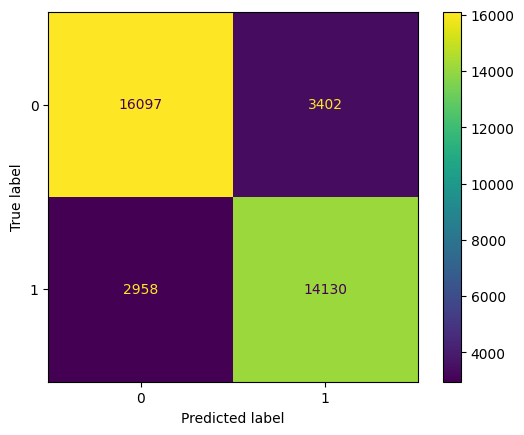

In [35]:
cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm).plot()
plt.show()

**Baseline results (2025–2026 test set):**
- Accuracy: 82.6%
- AUC: 0.917
- Log Loss: 0.360
- Brier Score: 0.118

This baseline is a genuine benchmark, not a strawman; 0.917 AUC is already strong. The question for XGBoost is whether it can meaningfully improve on this, not just match it.

# XGBoost Model

XGBoost is trained on the same feature set, without scaling since tree-based models split on raw feature values rather than distances.

## Training the Model

In [36]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(n_estimators = 101, max_depth = 8, learning_rate = 0.05, eval_metric = 'logloss', random_state = 304)
xg_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [37]:
xg_predictions = xg_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, xg_predictions))

Accuracy: 0.8369092847186159


In [38]:
xg_prob = xg_model.predict_proba(X_test)[:, 1]

## Evaluation Metrics

In [39]:
xg_auc_score = roc_auc_score(y_true = y_test, y_score = xg_prob)
print("Auc Score:", xg_auc_score)

xg_log_loss = log_loss(y_test, xg_prob)
print("Log Loss Score:", xg_log_loss)

xg_brier_score = brier_score_loss(y_test, xg_prob)
print("Brier Score:", xg_brier_score)

Auc Score: 0.923190597032922
Log Loss Score: 0.34805092769486756
Brier Score: 0.11253380496668858


## Classification Report

In [68]:
xg_class_report = classification_report(y_test, xg_predictions)
print("Classification Report:", '\n\n', xg_class_report)

Classification Report: 

               precision    recall  f1-score   support

           0       0.84      0.85      0.85     19499
           1       0.83      0.82      0.82     17088

    accuracy                           0.84     36587
   macro avg       0.84      0.84      0.84     36587
weighted avg       0.84      0.84      0.84     36587



## Confusion Matrix

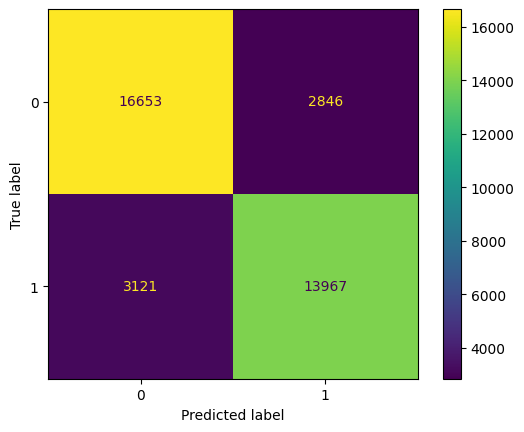

In [65]:
xg_cm = confusion_matrix(y_test, xg_predictions)
ConfusionMatrixDisplay(xg_cm).plot()
plt.show()

**XGBoost results (2025–2026 test set):**
- Accuracy: 83.6%
- AUC: 0.923
- Log Loss: 0.348
- Brier Score: 0.113

XGBoost improves on every metric, most notably log loss, which measures probability quality rather than just classification accuracy. Given this is a win probability model, log loss and Brier score matter more than accuracy alone.

# Calibration

AUC and accuracy show whether the model ranks outcomes correctly, but not whether the probabilities themselves are trustworthy. If the model says 70%, the chasing team should actually win about 70% of the time. Calibration curves check this for both models, then XGBoost gets isotonic calibration on top.

## Calibration Curves

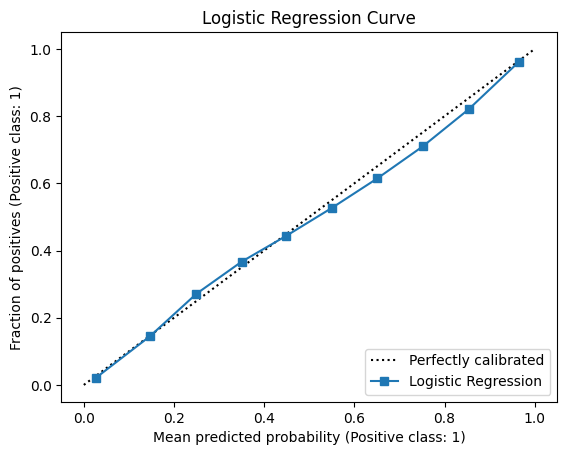

In [69]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, y_prob, n_bins = 10, name = "Logistic Regression")
plt.title("Logistic Regression Curve")
plt.show()

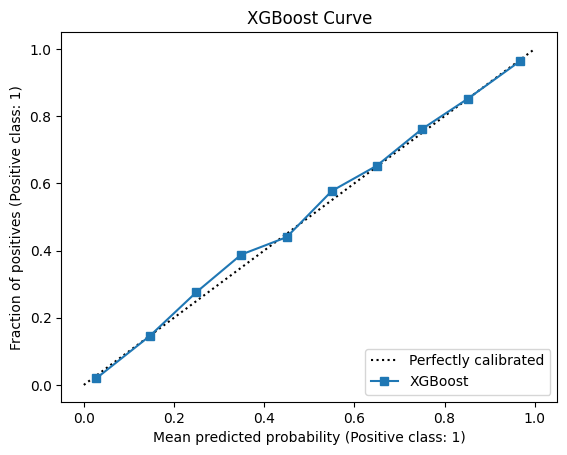

In [70]:
CalibrationDisplay.from_predictions(y_test, xg_prob, n_bins = 10, name = "XGBoost")
plt.title("XGBoost Curve")
plt.show()

## Isotonic Calibration

In [42]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_xg = CalibratedClassifierCV(xg_model, method='isotonic', cv='prefit')
calibrated_xg.fit(X_test, y_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [43]:
xg_prob_calib = calibrated_xg.predict_proba(X_test)[:, 1]

xg_auc_score_calib = roc_auc_score(y_true = y_test, y_score = xg_prob_calib)
print("Auc Score:", xg_auc_score_calib)

xg_log_loss_calib = log_loss(y_test, xg_prob_calib)
print("Log Loss Score:", xg_log_loss_calib)

xg_brier_score_calib = brier_score_loss(y_test, xg_prob_calib)
print("Brier Score:", xg_brier_score_calib)

Auc Score: 0.9235856703517688
Log Loss Score: 0.34494262377884466
Brier Score: 0.11192145708617912


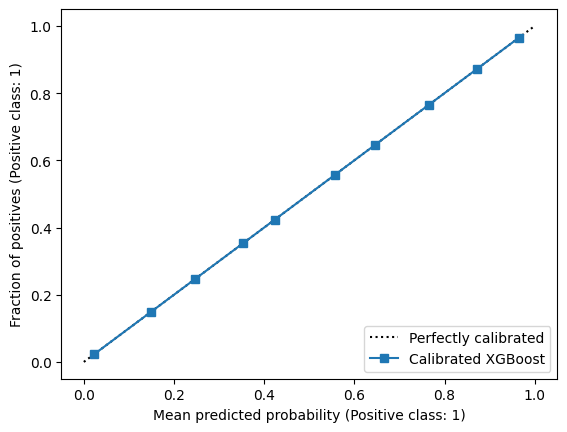

In [44]:
CalibrationDisplay.from_predictions(y_test, xg_prob_calib, n_bins = 10, name = "Calibrated XGBoost")
plt.show()

Both models are well calibrated overall. Logistic Regression tracks the diagonal slightly more closely in the 0.5–0.8 range, while XGBoost is better calibrated at the high-confidence end (0.8–1.0), the range that matters most in a live match since that's when a chase is nearly decided.

Isotonic calibration on XGBoost gave a marginal improvement (Brier Score 0.113 → 0.112). One limitation: the calibrator was fit on the test set itself (`cv='prefit'`) rather than a separate validation set, so this result is a bit optimistic. The underlying XGBoost model was trained correctly on separate data, only the calibration evaluation carries this caveat.

**Calibrated XGBoost is the final model used for the Streamlit app.**

# SHAP Analysis and Feature Selection

SHAP values break down each prediction into per-feature contributions, showing not just what matters globally but the direction and size of each feature's effect on a specific prediction. Used here both to understand the model and to check for redundant features.

## Computing SHAP Values

In [45]:
import shap

explainer = shap.TreeExplainer(xg_model)
shap_values = explainer.shap_values(X_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
pd.DataFrame(shap_values)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.066187,-0.032678,0.022104,0.086884,0.060751,0.231797,-0.434094,-0.377527,-0.381447,-0.030746,-1.009763,0.412503,-0.014873,-0.032604
1,0.001976,-0.032548,0.060350,0.012210,-0.042955,0.079876,-0.430773,-0.457250,-0.337322,0.000809,-0.812486,0.077169,-0.010238,-0.139632
2,-0.009649,-0.018570,0.108868,0.029778,-0.037483,0.055104,-0.514900,-0.617806,-0.324378,0.018338,0.096286,0.043364,0.002541,-0.195662
3,-0.029944,0.009379,0.116801,0.144597,-0.024869,0.002103,-0.189644,-0.655829,-0.828174,0.012655,1.536471,0.001460,0.043650,-0.026383
4,-0.019335,-0.041713,0.097445,0.252667,-0.023037,-0.105068,-0.209554,-0.450152,-0.631665,0.008002,0.943778,0.012858,0.017706,-0.029579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36582,-0.000034,-0.037196,0.031911,-0.048402,-0.024286,-0.276028,-0.088298,-0.390856,-0.303040,-0.039840,-4.199193,-0.074629,-0.024711,0.040591
36583,0.010182,-0.035310,0.033869,-0.044472,-0.010074,-0.383077,-0.083075,-0.380362,-0.291283,-0.037955,-4.132560,-0.074577,-0.020391,-0.001966
36584,0.012018,-0.036086,0.023114,-0.045123,0.000438,-0.603772,-0.083202,-0.409968,-0.256725,-0.032841,-3.879250,-0.071608,-0.015882,-0.088505
36585,0.012114,-0.035425,0.027302,-0.034016,0.011508,-0.811797,-0.089666,-0.389141,-0.247540,-0.033069,-3.741494,-0.094806,-0.014460,-0.156650


SHAP shows `remaining_balls` and `remaining_wickets` contribute zero marginal information, their signal is fully captured by the interaction term `wickets_x_balls`. Dropped both to simplify the model with no loss in performance.

## Feature Importance

In [47]:
shap_importance = pd.DataFrame({'feature': features, 'mean_abs_shap': np.abs(shap_values).mean(axis=0)}).sort_values('mean_abs_shap', ascending=False)
shap_importance

,feature,mean_abs_shap
10,crr_rrr_difference,1.477082
7,required_runs,0.475654
5,cumul_wickets,0.373637
8,rrr,0.362817
6,target,0.185306
11,wickets_x_balls,0.129647
1,venue,0.109777
13,wickets_in_last_3_overs,0.100056
3,bowling_team,0.071078
4,cumul_runs,0.059750


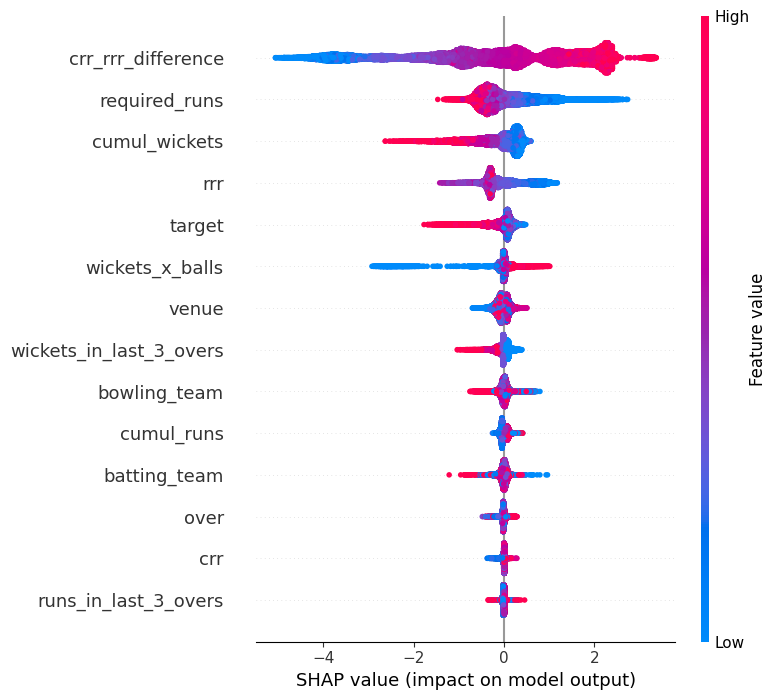

In [48]:
shap.summary_plot(shap_values, X_test, feature_names=features)

`crr_rrr_difference` is by far the most important feature, followed by `required_runs`, `cumul_wickets`, and `rrr`, exactly what a cricket fan would expect to matter most. Three features showed zero contribution: `remaining_balls`, `remaining_wickets`, and `match_phase`. Their signal is fully captured elsewhere (`wickets_x_balls` for the first two, `over` for the third), so they were dropped and the model retrained with no loss in performance.

# Case Studies: Famous Matches

To sanity-check the model against real matches, win probability curves are generated for two iconic finals: India vs South Africa (T20 World Cup Final 2024) and Mumbai Indians vs Chennai Super Kings (IPL Final 2019). Both are famous for their dramatic swings, making them a good test of whether the model's curve matches the actual flow of the match.

## India vs South Africa, T20 World Cup Final 2024

In [49]:
df_over[(df_over['competition'].str.contains('World Cup', case=False, na=False)) & (df_over["season"] == 2024) & (df_over["batting_team"] == "South Africa") & (df_over["bowling_team"] == "India")][['match_id', 'date', 'competition', 'batting_team', 'bowling_team']].drop_duplicates('match_id')

,match_id,date,competition,batting_team,bowling_team
90729,1415755,2024-06-29,ICC Men's T20 World Cup,South Africa,India


In [50]:
india_sa = df_model[df_over["match_id"] == "1415755"][features]
india_sa

/var/folders/n_/hd4whr8972b54sv4t6_db9d80000gn/T/ipykernel_82103/2552907880.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  india_sa = df_model[df_over["match_id"] == "1415755"][features]


,over,venue,batting_team,bowling_team,cumul_runs,cumul_wickets,target,required_runs,rrr,crr,crr_rrr_difference,wickets_x_balls,runs_in_last_3_overs,wickets_in_last_3_overs
90729,0,199,193,95,6,0,177,171,9.000000,6.000000,-3.000000,1140,6,0
90730,1,199,193,95,11,1,177,166,9.222222,5.500000,-3.722222,972,11,1
90731,2,199,193,95,14,2,177,163,9.588235,4.666667,-4.921569,816,14,2
90732,3,199,193,95,22,2,177,155,9.687500,5.500000,-4.187500,768,16,2
90733,4,199,193,95,32,2,177,145,9.666667,6.400000,-3.266667,720,21,1
90734,5,199,193,95,42,2,177,135,9.642857,7.000000,-2.642857,672,28,0
90735,6,199,193,95,49,2,177,128,9.846154,7.000000,-2.846154,624,27,0
90736,7,199,193,95,62,2,177,115,9.583333,7.750000,-1.833333,576,30,0
90737,8,199,193,95,71,3,177,106,9.636364,7.888889,-1.747475,462,29,1
90738,9,199,193,95,81,3,177,96,9.600000,8.100000,-1.500000,420,32,1


In [51]:
india_sa_prob = calibrated_xg.predict_proba(india_sa)[:, 1]

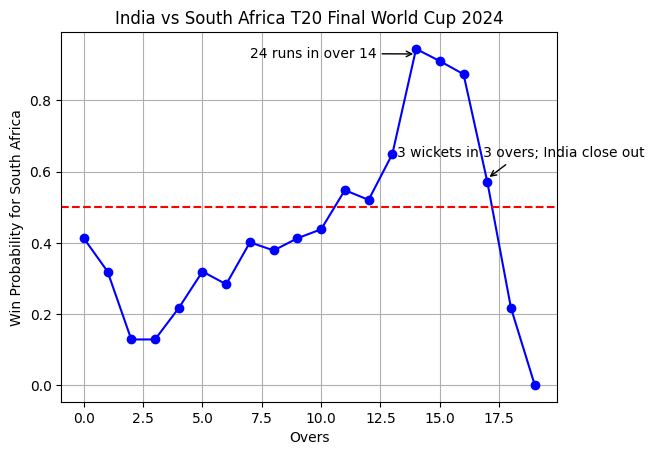

In [71]:
plt.plot(india_sa["over"], india_sa_prob, color = 'blue', marker = 'o')
plt.axhline(y = 0.5, color = 'red', linestyle = '--', label = '50% mark')
plt.annotate('24 runs in over 14', xy = (14, 0.93), xytext = (7, 0.92), arrowprops = dict(arrowstyle='->'))
plt.annotate('3 wickets in 3 overs; India close out', xy = (17, 0.58), xytext = (13.2, 0.64), arrowprops = dict(arrowstyle='->'))
plt.title("India vs South Africa T20 Final World Cup 2024")
plt.xlabel("Overs")
plt.ylabel("Win Probability for South Africa")
plt.grid(True)
plt.show()

## Mumbai Indians vs Chennai Super Kings, IPL Final 2019

In [53]:
df_over[(df_over['competition'].str.contains('Indian Premier League', case=False, na=False)) & (df_over["season"] == 2019) & (df_over["batting_team"] == "Chennai Super Kings") & (df_over["bowling_team"] == "Mumbai Indians")][['match_id', 'date', 'competition', 'batting_team', 'bowling_team']].drop_duplicates('match_id')

,match_id,date,competition,batting_team,bowling_team
22508,1175370,2019-04-03,Indian Premier League,Chennai Super Kings,Mumbai Indians
23292,1178419,2019-04-26,Indian Premier League,Chennai Super Kings,Mumbai Indians
23645,1181768,2019-05-12,Indian Premier League,Chennai Super Kings,Mumbai Indians


The match on 2019-05-12 (1181768) is the Final.

In [54]:
mi_csk = df_model[df_over["match_id"] == "1181768"][features]
mi_csk

/var/folders/n_/hd4whr8972b54sv4t6_db9d80000gn/T/ipykernel_82103/1279676696.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mi_csk = df_model[df_over["match_id"] == "1181768"][features]


,over,venue,batting_team,bowling_team,cumul_runs,cumul_wickets,target,required_runs,rrr,crr,crr_rrr_difference,wickets_x_balls,runs_in_last_3_overs,wickets_in_last_3_overs
23645,0,324,31,144,7,0,150,143,7.526316,7.000000,-0.526316,1140,7,0
23646,1,324,31,144,12,0,150,138,7.666667,6.000000,-1.666667,1080,12,0
23647,2,324,31,144,19,0,150,131,7.705882,6.333333,-1.372549,1020,19,0
23648,3,324,31,144,33,1,150,117,7.312500,8.250000,0.937500,864,26,1
23649,4,324,31,144,38,1,150,112,7.466667,7.600000,0.133333,810,26,1
23650,5,324,31,144,53,1,150,97,6.928571,8.833333,1.904762,756,34,1
23651,6,324,31,144,57,1,150,93,7.153846,8.142857,0.989011,702,24,0
23652,7,324,31,144,60,1,150,90,7.500000,7.500000,0.000000,648,22,0
23653,8,324,31,144,70,1,150,80,7.272727,7.777778,0.505051,594,17,0
23654,9,324,31,144,72,2,150,78,7.800000,7.200000,-0.600000,480,15,1


In [55]:
mi_csk_prob = calibrated_xg.predict_proba(mi_csk)[:, 1]

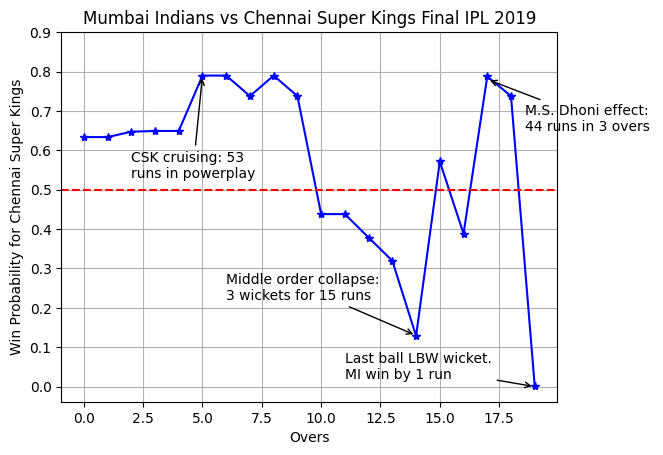

In [56]:
plt.plot(mi_csk["over"], mi_csk_prob, color = 'blue', marker = '*')
plt.axhline(y = 0.5, color = 'red', linestyle = '--', label = '50% mark')

plt.annotate('CSK cruising: 53 \nruns in powerplay', xy = (5, 0.79), xytext = (2, 0.53), arrowprops = dict(arrowstyle='->'))
plt.annotate('Middle order collapse: \n3 wickets for 15 runs', xy = (14, 0.13), xytext = (6, 0.22), arrowprops = dict(arrowstyle='->'))
plt.annotate('Last ball LBW wicket.\nMI win by 1 run', xy = (19, 0), xytext = (11, 0.02), arrowprops = dict(arrowstyle='->'))
plt.annotate('M.S. Dhoni effect: \n44 runs in 3 overs', xy = (17, 0.78), xytext = (18.6, 0.65), arrowprops = dict(arrowstyle='->'))

plt.title("Mumbai Indians vs Chennai Super Kings Final IPL 2019")
plt.xlabel("Overs")
plt.ylabel("Win Probability for Chennai Super Kings")
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.grid(True)
plt.show()

Both curves track the real match narrative closely. South Africa's probability spikes to 93% after a 24-run over, then collapses to near 0% as three wickets fall in the final three overs. CSK's probability swings from 79% in the powerplay down to 13% during a middle-order collapse, back up to 78% during Dhoni's late assault, before crashing to 0% on the final-ball dismissal that decided the match by one run. These extend to a set of 21 famous T20 matches in the deployed Streamlit app.

# Saving Model Artifacts

Model, medians for the rolling features, and label encoders are saved here for use in the deployed Streamlit app.

In [57]:
import joblib
joblib.dump(calibrated_xg, 'model.pkl')

['model.pkl']

In [58]:
median_runs_last3 = X_train['runs_in_last_3_overs'].median()
median_wickets_last3 = X_train['wickets_in_last_3_overs'].median()

In [59]:
joblib.dump({
    'median_runs_last3': median_runs_last3,
    'median_wickets_last3': median_wickets_last3
}, 'medians.pkl')

['medians.pkl']

In [60]:
joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

# Summary

**Final model:** XGBoost with isotonic calibration, trained on 10,458 T20 matches across 10 leagues (2008-2024), evaluated on genuinely unseen 2025-2026 matches.

**Final test set performance:** AUC 0.924, Log Loss 0.345, Brier Score 0.112, improving on the Logistic Regression baseline across every metric.

**Key decisions:**
- Temporal train/test split to prevent data leakage
- Feature selection informed by SHAP rather than intuition alone
- Post-hoc calibration validated with calibration curves, not just assumed
- Case studies against real matches as a sanity check beyond aggregate metrics

**Known limitations:**
- Calibration was evaluated on the test set itself rather than a separate validation set
- Venue defaults to a fixed value in the deployed app's Live Predictor, since asking users for exact venue names isn't practical
- The model performs poorly on extreme last-ball scenarios, which are rare edge cases where historical data is sparse

**Deployment:** live at [cricket-t20-win-probability.streamlit.app](https://cricket-t20-win-probability.streamlit.app), with 5 pages covering the live predictor, full match replay, famous matches, model insights, and the feature engineering pipeline.